##**WorkWearClassifier**

###**Objective:**
Build an AI system to classify individual clothing items as work-appropriate or not work-appropriate.
This system will serve as a foundation for a future outfit recommendation tool.

It will use convolutional neural networks (CNNs) trained on labeled clothing images.
Performance will be evaluated using accuracy and other relevant metrics.

In [ ]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import seaborn as sns
import random

# Setting the RANDOM_STATE
# A number used to initialize the random number generators in Python, NumPy, TensorFlow
# Ensures that results are reproducible
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Load the Fashion MNIST dataset
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

###**Fashion MNIST Dataset**
Contains 70,000 grayscale images of size 28x28 pixels, divided into:
*   Training set: 60,000 images
*   Test set: 10,000 images

Each images represents one of 10 fashion item categories:
*   **0**: T-shirt/top
*   **1**: Trouser
*   **2**: Pullover
*   **3**: Dress
*   **4**: Coat
*   **5**: Sandal
*   **6**: Shirt
*   **7**: Sneaker
*   **8**: Bag
*   **9**: Ankle Boot

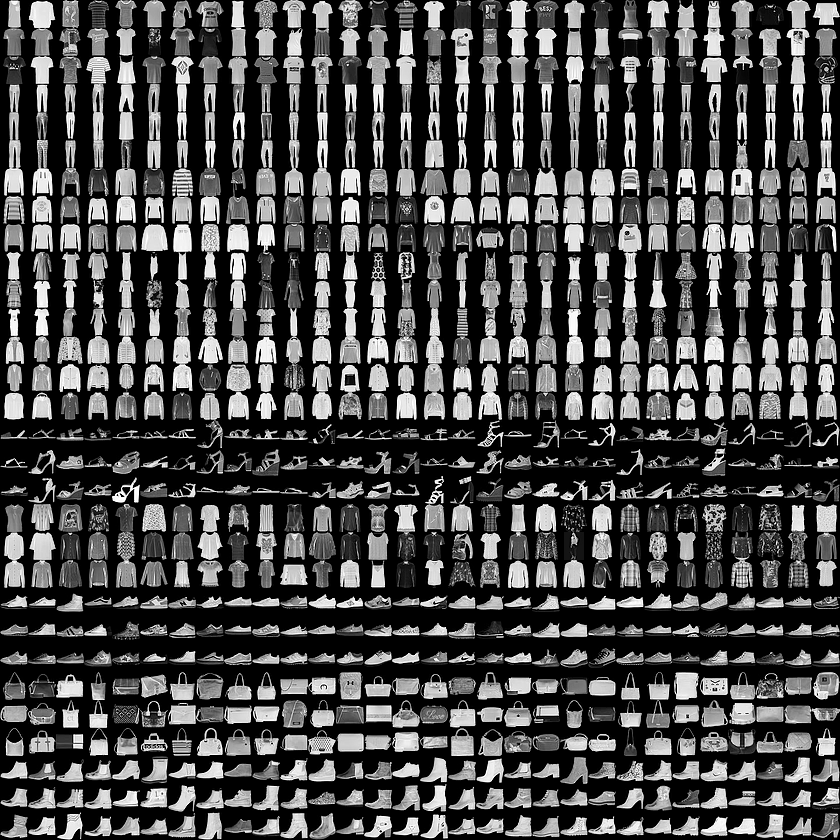

##Data Processing and Analysis

In [ ]:
# Preprocess the data (normalize pixel values)
# Normalize pixel values to range 0-1
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for CNN/DNN input (height, width, channels)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# The shape of training and test dataset
# Print dataset shapes
print("Training dataset shape",X_train.shape)
print("Test dataset shape",X_test.shape)

# Fashion MNIST class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print("class names:", class_names)

Training dataset shape (60000, 28, 28, 1)
Test dataset shape (10000, 28, 28, 1)
class names: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## **Display Class Distribution Function**

> Add blockquote

> Add blockquote

> Add blockquote






### Displaying Number of Images in Each Class

Calculates the number of images in each class

*   Pass train_labels as the parameter for the function
*   Print the name of item and count
*   Display a bar chart

T-shirt/top : 1000
Trouser : 1000
Pullover : 1000
Dress : 1000
Coat : 1000
Sandal : 1000
Shirt : 1000
Sneaker : 1000
Bag : 1000
Ankle boot : 1000


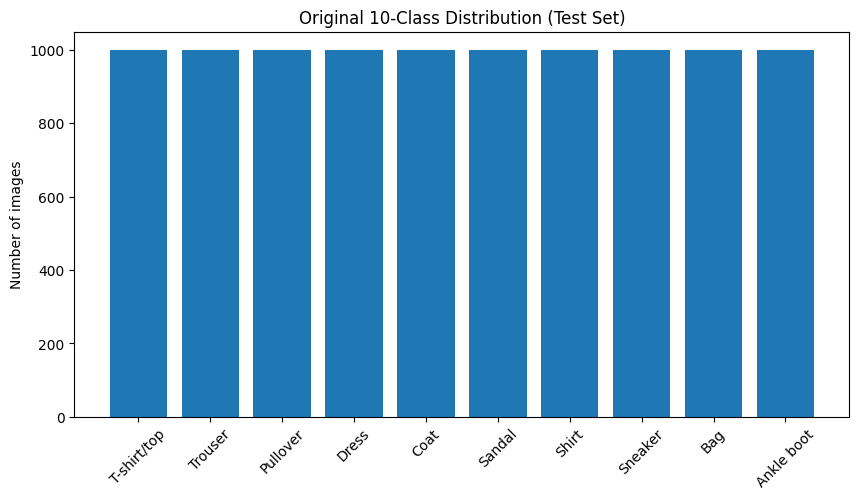

In [ ]:
from pandas.core.api import Index

# Function to display original 10-class distribution
def display_class_distribution(train_labels, title = 'Distribution of Classes:'):

  # Create the index
  index = pd.Index(train_labels)

  # Count the number of values in the index and then sort
  # Counts how many images belong to each class
  # Sorts them so that class labels are in ascending order
  count = index.value_counts().sort_index()

  # Print counts for each class
  for i, c in enumerate(count):
    print(f"{class_names[i]} : {c}")

  # Bar chart
  plt.figure(figsize = (10,5))
  plt.bar(count.index, count.values)
  plt.xticks(range(10), class_names, rotation=45)
  plt.ylabel('Number of images')
  plt.title(title)


#Display original class distribution for training set
display_class_distribution(y_test, title = 'Original 10-Class Distribution (Test Set)')

## **Work-Appropriate / Not Work-Appropriate**

### Work-Appropriate:
*   **1**: Trousers
*   **2**: Pullover
*   **3**: Dress
*   **4**: Coat
*   **6**: Shirt

In [ ]:
work_classes = [1,2,3,4,6]

# Binary Labels:
# 1 = work-appropriate
# 2 = not work-appropriate

y_train_binary = np.array([1 if label in work_classes else 0 for label in y_train])
y_test_binary = np.array([1 if label in work_classes else 0 for label in y_test])

# One-hot encode for model training (needed for CNN later)
from tensorflow.keras.utils import to_categorical
y_train_binary = to_categorical(y_train_binary, 2)
y_test_binary = to_categorical(y_test_binary, 2)

print("y_train_binary shape:", y_train_binary.shape)
print("y_test_binary shape:", y_test_binary.shape)

y_train_binary shape: (60000, 2)
y_test_binary shape: (10000, 2)


## **Binary Work-Appropriate Distribution (Training Set)**
*   **1**: Work-Appropriate
*   **0**: Not Work-Appropriate

Work-appropriate images (training set): 30000
Not work-appropriate images (training set): 30000


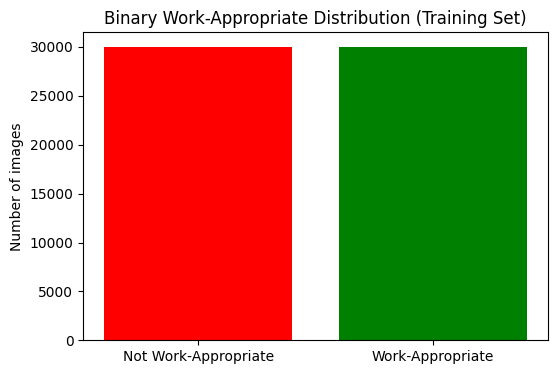

In [ ]:
# Binary work-appropriate distribution (training set)
work_count = np.sum(y_train_binary[:,1])
not_work_count = np.sum(y_train_binary[:,0])

print(f"Work-appropriate images (training set): {int(work_count)}")
print(f"Not work-appropriate images (training set): {int(not_work_count)}")

# Bar chart
plt.figure(figsize = (6,4))
plt.bar(['Not Work-Appropriate', 'Work-Appropriate'], [not_work_count, work_count], color = ['red', 'green'])
plt.ylabel('Number of images')
plt.title('Binary Work-Appropriate Distribution (Training Set)')
plt.show()

## **Splitting the Training Dataset into Training and Validation**

Work-appropriate images (validation set): 6028
Not work-appropriate images (validation set): 5972


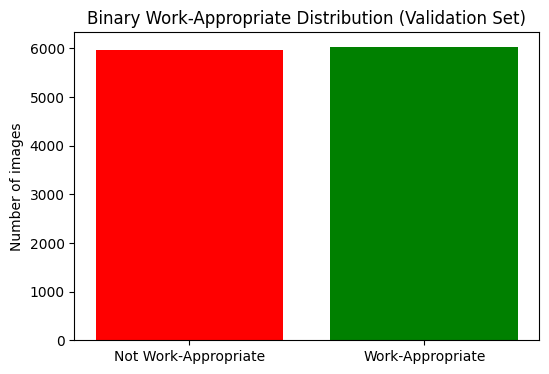

In [ ]:
from sklearn.model_selection import train_test_split

# Split the train and the validation set (X_val, y_val) using train_teset_split
# Training set (X_train, y_train_binary): used to train the CNN
# Validation set (X_val, y_val_binary): used to test the model during training, but not for updating weights

# 20% of training data is reserved for validation
X_train, X_val, y_train_binary, y_val_binary = train_test_split(X_train, y_train_binary, test_size = 0.2, random_state = RANDOM_STATE)

# Binary validation distribution

# y_val_binary: one-hot encoded
# [1,0]: not work-appropriate
# [0,1]: work-appropriate
val_work_count = np.sum(y_val_binary[:,1])
val_not_work_count = np.sum(y_val_binary[:,0])

# Prints how many images in the validation set are work-appropriate vs not work-appropriate
print(f"Work-appropriate images (validation set): {int(val_work_count)}")
print(f"Not work-appropriate images (validation set): {int(val_not_work_count)}")

plt.figure(figsize=(6,4))
plt.bar(['Not Work-Appropriate', 'Work-Appropriate'], [val_not_work_count, val_work_count], color=['red', 'green'])
plt.ylabel('Number of images')
plt.title('Binary Work-Appropriate Distribution (Validation Set)')
plt.show()

In [ ]:
# Stats for the Fashion MNIST train, validation, and test dataset
print("Fashion MNIST train -  rows:", X_train.shape[0], " columns:", X_train.shape[1:4])
print("Fashion MNIST validation -  rows:", X_val.shape[0], " columns:", X_val.shape[1:4])
print("Fashion MNIST test -  rows:", X_test.shape[0], " columns:", X_test.shape[1:4])

Fashion MNIST train -  rows: 48000  columns: (28, 28, 1)
Fashion MNIST validation -  rows: 12000  columns: (28, 28, 1)
Fashion MNIST test -  rows: 10000  columns: (28, 28, 1)


## **Defining Binary DNN Model**

In [ ]:
# Import Sequential
from keras.models import Sequential

# Import Dense and Flatten
from keras.layers import Dense
from keras.layers import Flatten

# Sequential: the model is a linear stak of layers. Good for simple feedforward networks
model = Sequential()

# Flatten input (28x28x1 -> 784)
# Flatten: converts 2D image (28x28 pixels, 1 channel) into 1D vector (size = 784)
model.add(Flatten(input_shape = (28,28,1), name = "inputLayer"))

# Hidden layer: with 128 neurons and ReLu activation
# ReLu: non-linearity
model.add(Dense(128, activation = 'relu', name = "hidddenLayer"))

# Output layer (2 classes: work-appropriate/not work-appropriate) with softmax activation
# softmax: probabilities that sume to 1 for each class. For one-hot encoded labels (y_train_binary)
model.add(Dense(2, activation = 'softmax', name = "outputLayer"))

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputLayer (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidddenLayer (Dense)            │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputLayer (Dense)             │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,738 (393.51 KB)

 Trainable params: 100,738 (393.51 KB)

 Non-trainable params: 0 (0.00 B)

## **compile_and_fit Function**
A resuable helper function that compiles and trains your neural network model. Takes the model and training parameters as input and returns the training history.

In [ ]:
def compile_and_fit(model, loss_function, optimizer, metrics, epochs, batch_size):

    # Compile model
    model.compile(optimizer = optimizer,
                  loss = loss_function,
                  metrics = metrics)

    # Fit model
    history = model.fit(X_train,
                        y_train_binary,
                        epochs = epochs,
                        validation_data = (X_val, y_val_binary),
                        batch_size = batch_size)

    # Return history
    return history

# Parameters
MODEL = model
LOSS_FUNCTION = "categorical_crossentropy"
OPTIMIZER = "adam"
METRICS = ["accuracy"]
EPOCHS = 15
BATCH_SIZE = 32

# Train the model
history = compile_and_fit(model=MODEL,
                          loss_function = LOSS_FUNCTION,
                          optimizer = OPTIMIZER,
                          metrics = METRICS,
                          epochs = EPOCHS,
                          batch_size = BATCH_SIZE)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9372 - loss: 0.1519 - val_accuracy: 0.9535 - val_loss: 0.1126
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9568 - loss: 0.1012 - val_accuracy: 0.9573 - val_loss: 0.1052
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9598 - loss: 0.0921 - val_accuracy: 0.9581 - val_loss: 0.1015
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9628 - loss: 0.0853 - val_accuracy: 0.9600 - val_loss: 0.0981
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9657 - loss: 0.0809 - val_accuracy: 0.9597 - val_loss: 0.0968
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9671 - loss: 0.0763 - val_accuracy: 0.9600 - val_loss: 0.0969
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9696 - loss: 0.0729 - val_accuracy: 0.9595 - val_loss: 0.0960
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9710 - loss: 0.0685 

## **Evaluate and Plot Performance**
### Plot training and validation accuracy across epochs

Train Accuracy: 0.977, Validation Accuracy: 0.961


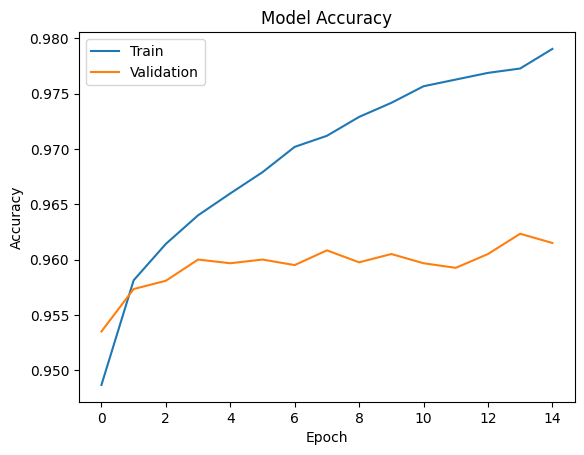

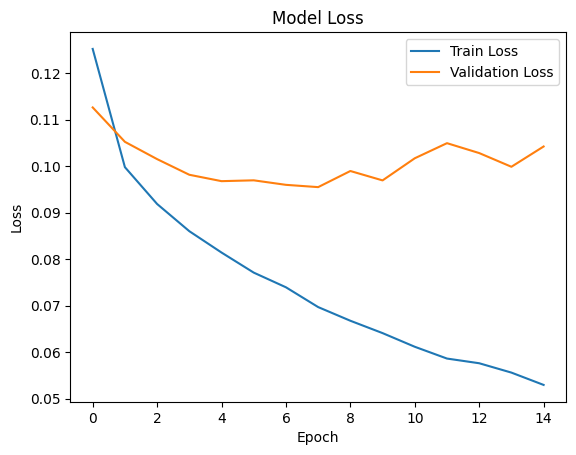

In [ ]:
# Evaluate train and validation accuracy
_, train_acc = model.evaluate(X_train, y_train_binary, verbose=0)
_, val_acc = model.evaluate(X_val, y_val_binary, verbose=0)
print('Train Accuracy: %.3f, Validation Accuracy: %.3f' % (train_acc, val_acc))

def display_performance(history):
  # Plot training accuracy (from history) and validation accuracy
  plt.plot(history.history['accuracy'], label = 'Train')
  plt.plot(history.history['val_accuracy'], label = 'Validation')

  # Add title and axis labels
  plt.title('Model Accuracy')
  plt.ylabel('Accuracy')
  plt.xlabel('Epoch')

  # Show the legend
  plt.legend()

  # Display the accuracy plot
  plt.show()

  # Plot training loss and validation loss
  plt.plot(history.history['loss'], label = 'Train Loss')
  plt.plot(history.history['val_loss'], label = 'Validation Loss')

  # Add title and axis labels
  plt.title('Model Loss')
  plt.ylabel('Loss')
  plt.xlabel('Epoch')

  # Show the legend
  plt.legend()

  plt.show()

display_performance(history)

## **Display the Test Results**

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


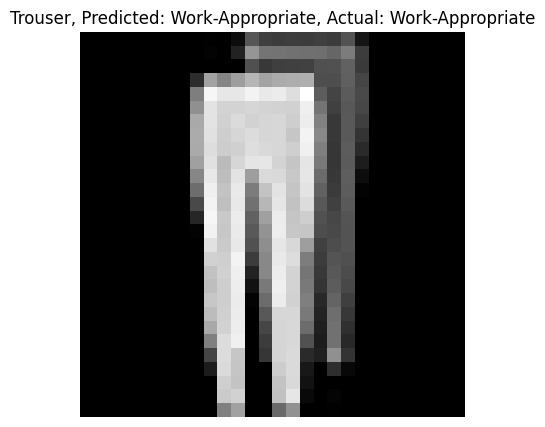

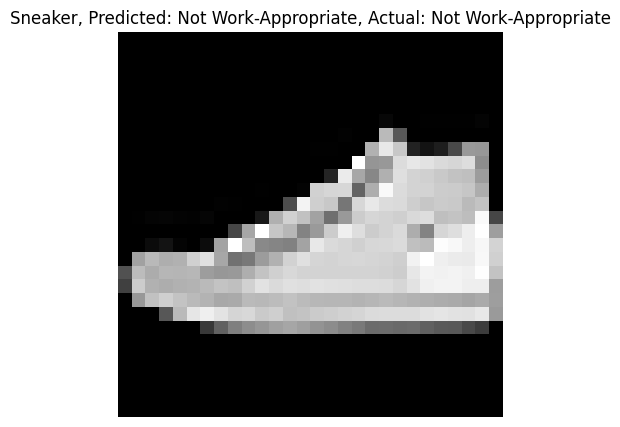

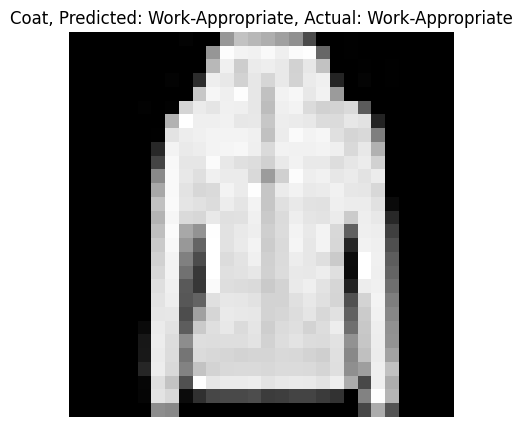

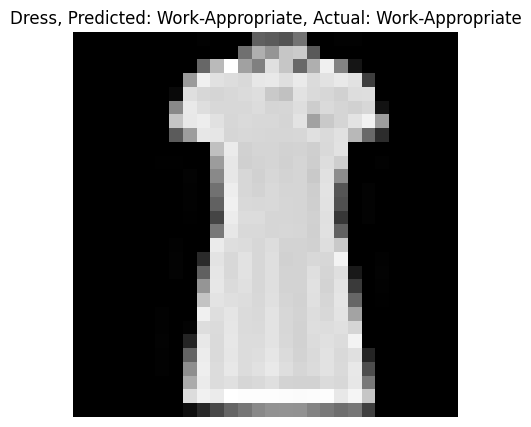

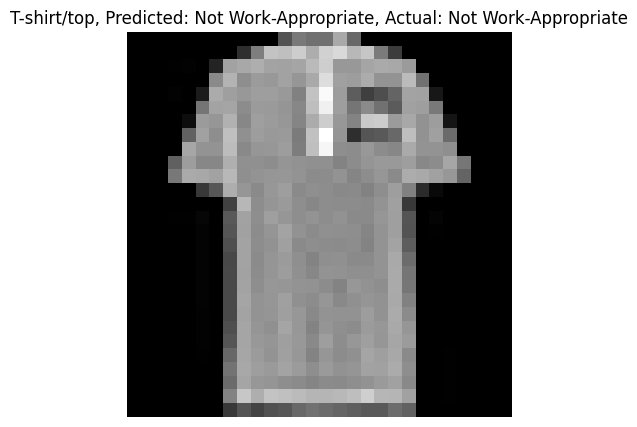

In [ ]:
# Get prediction for the test set using binary classifier

# Outputs probabilities for [Not-Work Appropriate, Work-Appropriate]
y_pred_binary = np.argmax(model.predict(X_test), axis=-1)

# Show 5 random test images and predictions
num_samples = 5

for i in range(num_samples):
    plt.figure(figsize=(5,5))
    index = random.randint(0, len(X_test)-1)

    item_class = class_names[y_test[index]]

    #  Display the predicted class, actual class, and corresponding class names
    predicted_label = y_pred_binary[index]
    actual_label = np.argmax(y_test_binary[index])
    label_names = ["Not Work-Appropriate", "Work-Appropriate"]

    plt.title(f"{item_class}, Predicted: {label_names[predicted_label]}, Actual: {label_names[actual_label]}")
    plt.imshow(X_test[index].reshape(28,28), cmap='gray')
    plt.axis('off')
    plt.show()


## **Tank Top vs. T-Shirt/Top Classifier**

Epoch 1/10
1500/1500 - 8s - 6ms/step - accuracy: 0.9894 - loss: 0.0390 - val_accuracy: 0.9912 - val_loss: 0.0286
Epoch 2/10
1500/1500 - 6s - 4ms/step - accuracy: 0.9930 - loss: 0.0249 - val_accuracy: 0.9933 - val_loss: 0.0224
Epoch 3/10
1500/1500 - 8s - 5ms/step - accuracy: 0.9945 - loss: 0.0183 - val_accuracy: 0.9937 - val_loss: 0.0212
Epoch 4/10
1500/1500 - 8s - 6ms/step - accuracy: 0.9959 - loss: 0.0146 - val_accuracy: 0.9945 - val_loss: 0.0199
Epoch 5/10
1500/1500 - 7s - 5ms/step - accuracy: 0.9967 - loss: 0.0116 - val_accuracy: 0.9946 - val_loss: 0.0217
Epoch 6/10
1500/1500 - 7s - 5ms/step - accuracy: 0.9971 - loss: 0.0099 - val_accuracy: 0.9948 - val_loss: 0.0201
Epoch 7/10
1500/1500 - 7s - 5ms/step - accuracy: 0.9978 - loss: 0.0078 - val_accuracy: 0.9942 - val_loss: 0.0199
Epoch 8/10
1500/1500 - 7s - 5ms/step - accuracy: 0.9976 - loss: 0.0076 - val_accuracy: 0.9937 - val_loss: 0.0245
Epoch 9/10
1500/1500 - 6s - 4ms/step - accuracy: 0.9981 - loss: 0.0060 - val_accuracy: 0.9940 - 

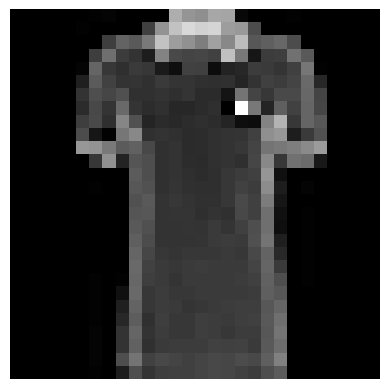

Is this a tank top? (y/n): n


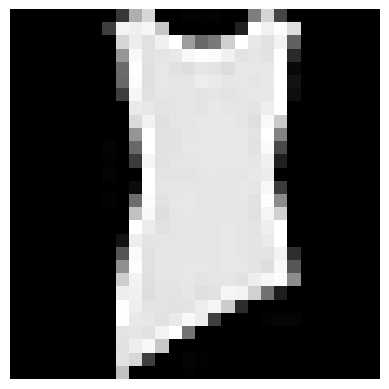

Is this a tank top? (y/n): y


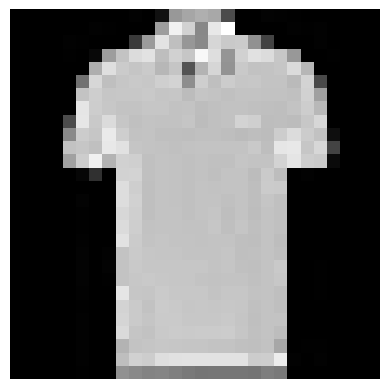

Is this a tank top? (y/n): n


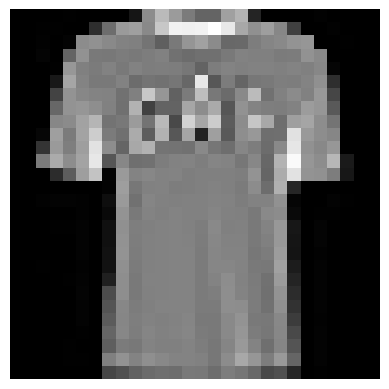

Is this a tank top? (y/n): n


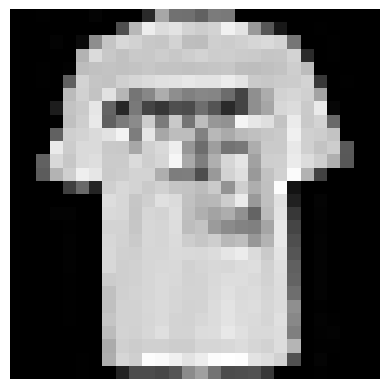

Is this a tank top? (y/n): n


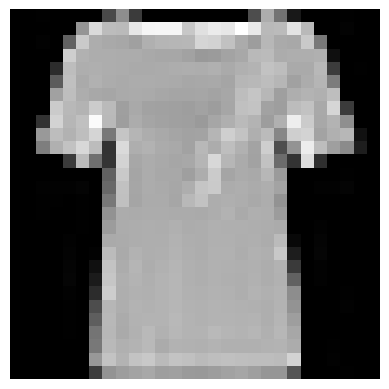

Is this a tank top? (y/n): n


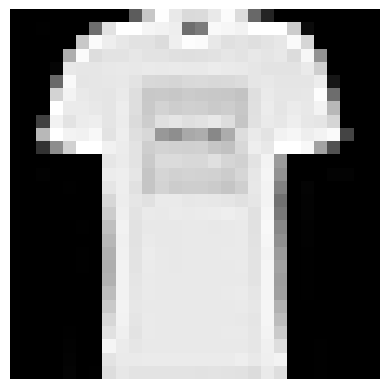

Is this a tank top? (y/n): n


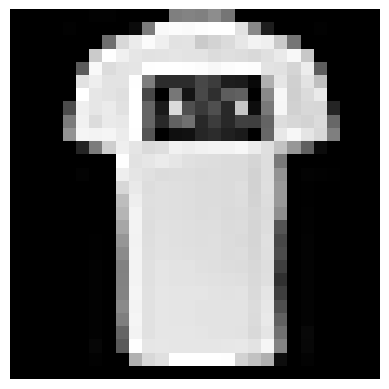

Is this a tank top? (y/n): n


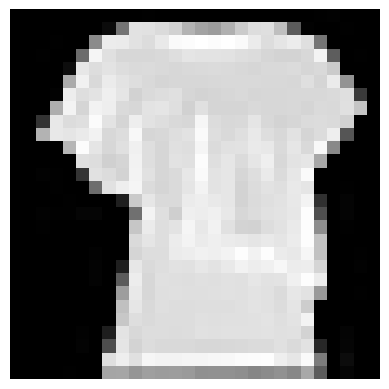

Is this a tank top? (y/n): n


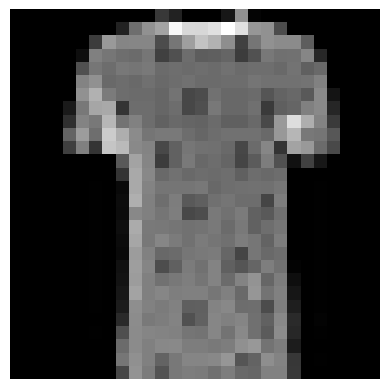

Is this a tank top? (y/n): n


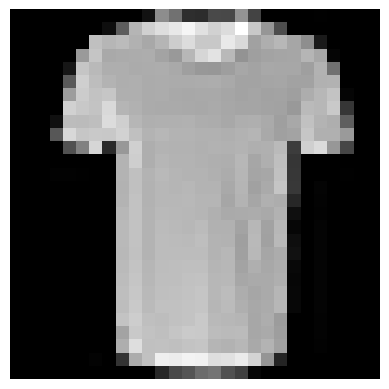

Is this a tank top? (y/n): n


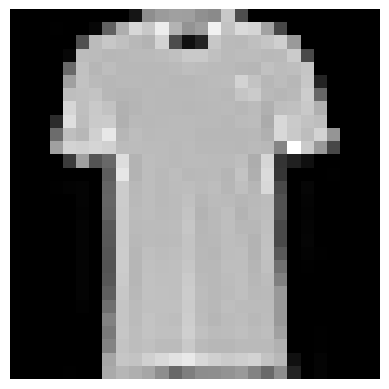

Is this a tank top? (y/n): n


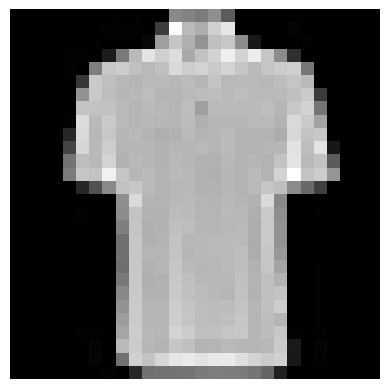

Is this a tank top? (y/n): n


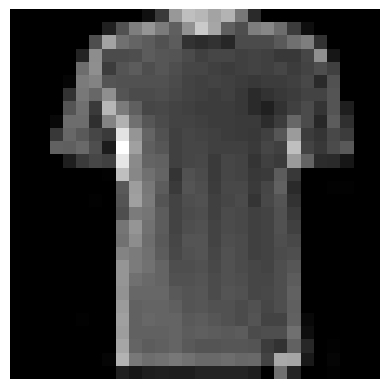

Is this a tank top? (y/n): n


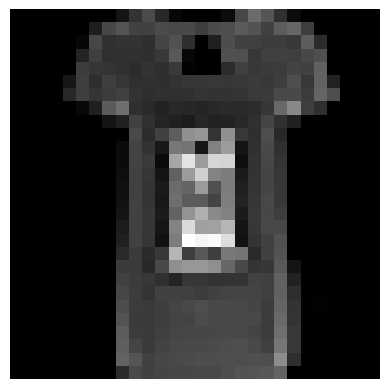

Is this a tank top? (y/n): n


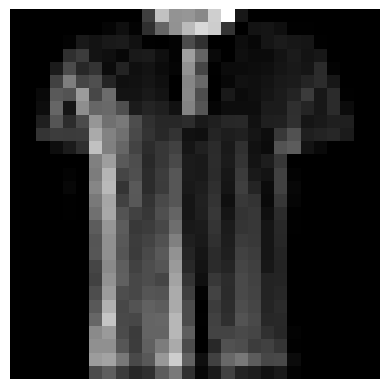

Is this a tank top? (y/n): n


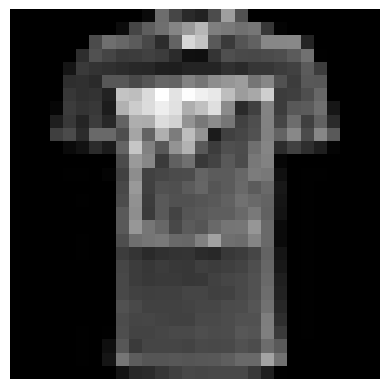

Is this a tank top? (y/n): n


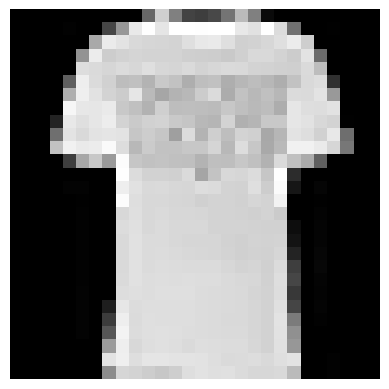

Is this a tank top? (y/n): n


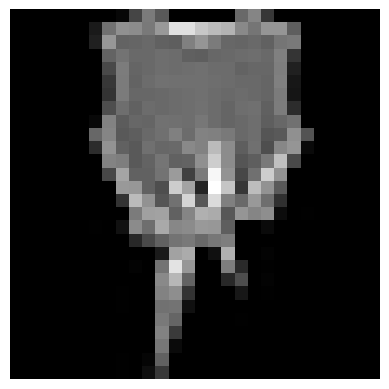

Is this a tank top? (y/n): y


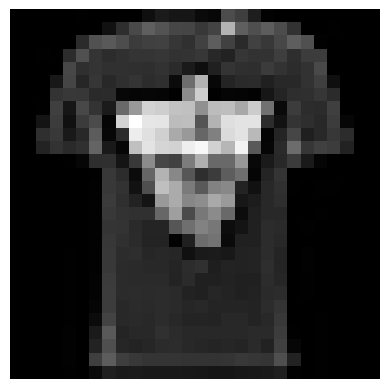

Is this a tank top? (y/n): n


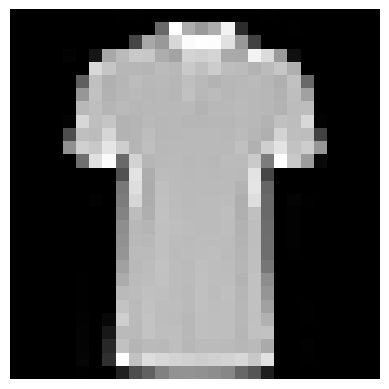

Is this a tank top? (y/n): n


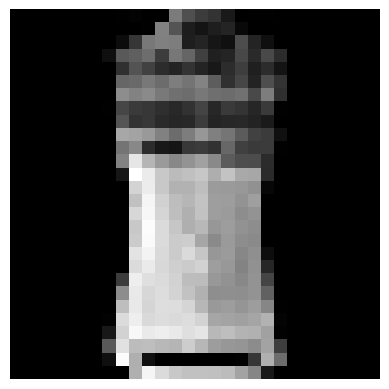

Is this a tank top? (y/n): y


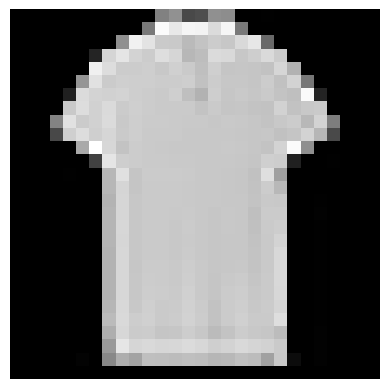

Is this a tank top? (y/n): n


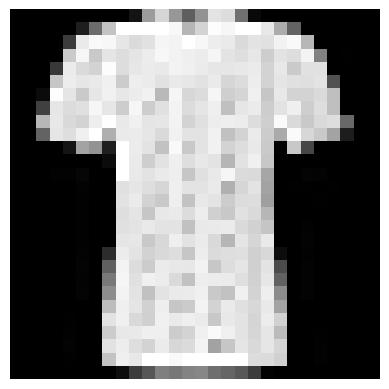

Is this a tank top? (y/n): n


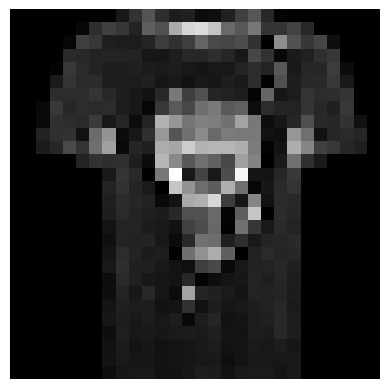

Is this a tank top? (y/n): n


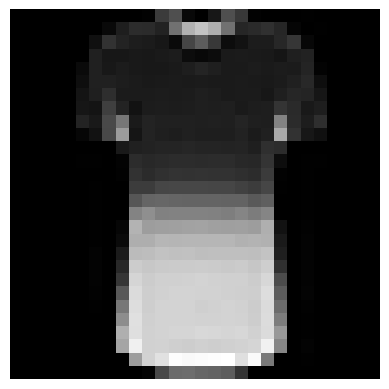

Is this a tank top? (y/n): n


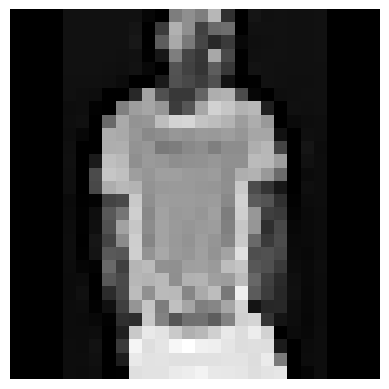

Is this a tank top? (y/n): n


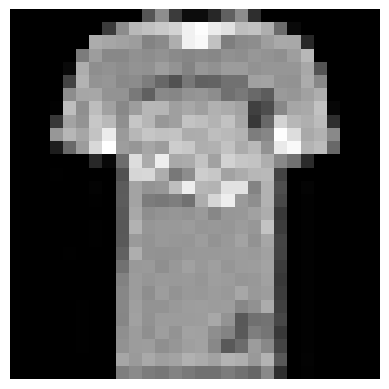

Is this a tank top? (y/n): n


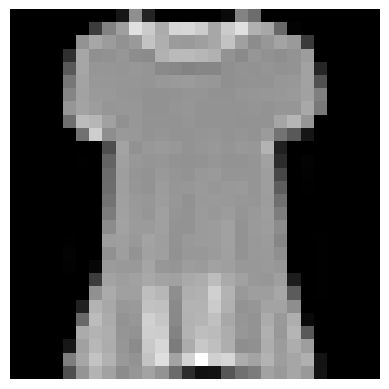

Is this a tank top? (y/n): n


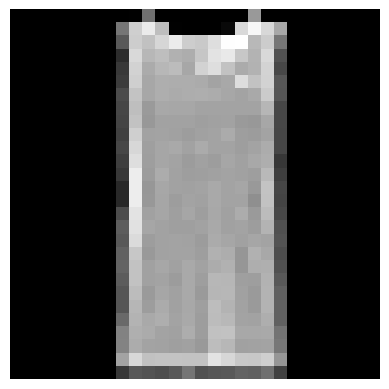

Is this a tank top? (y/n): y


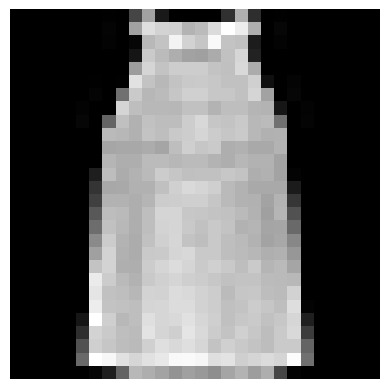

Is this a tank top? (y/n): y


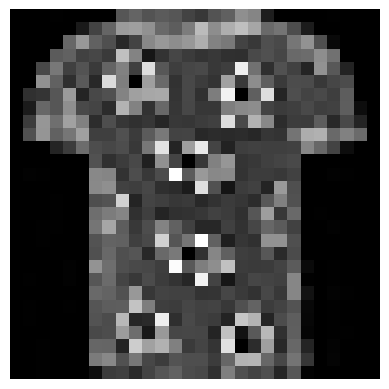

Is this a tank top? (y/n): n


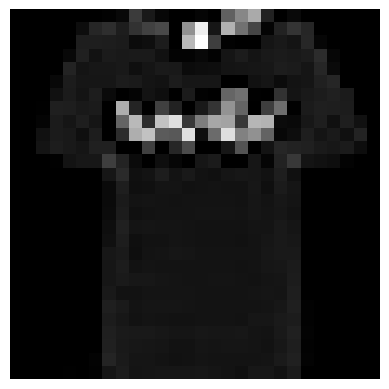

Is this a tank top? (y/n): n


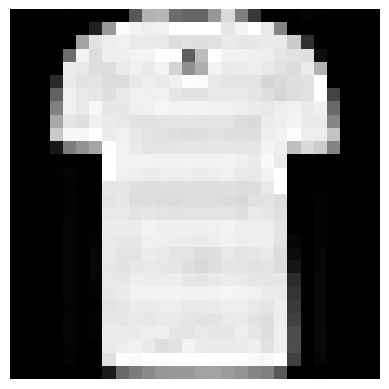

Is this a tank top? (y/n): n


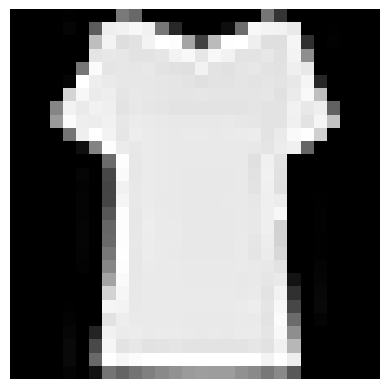

Is this a tank top? (y/n): n


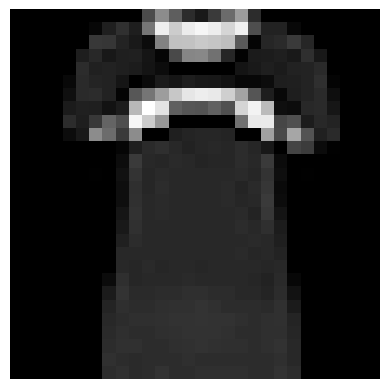

Is this a tank top? (y/n): n


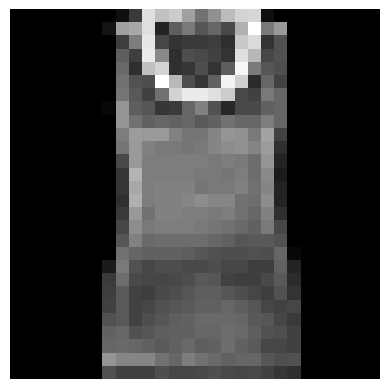

Is this a tank top? (y/n): y


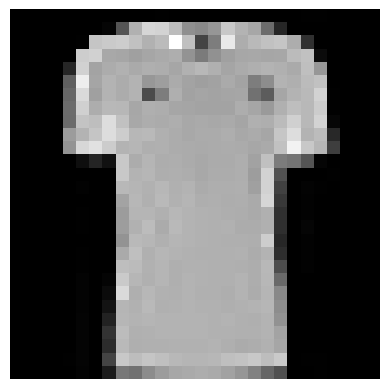

Is this a tank top? (y/n): n


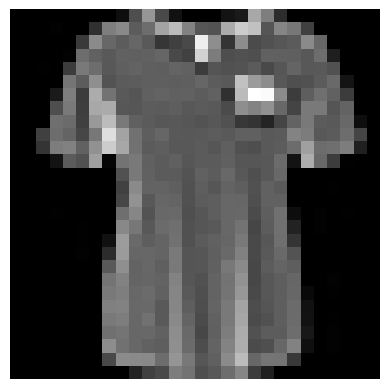

Is this a tank top? (y/n): n


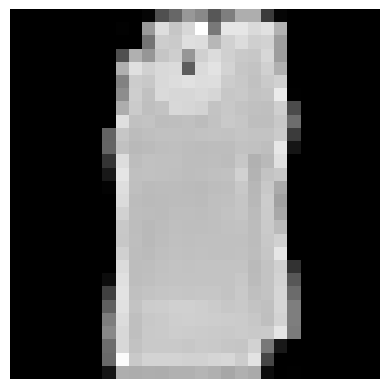

Is this a tank top? (y/n): y


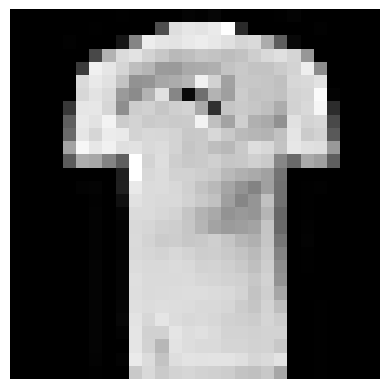

Is this a tank top? (y/n): n


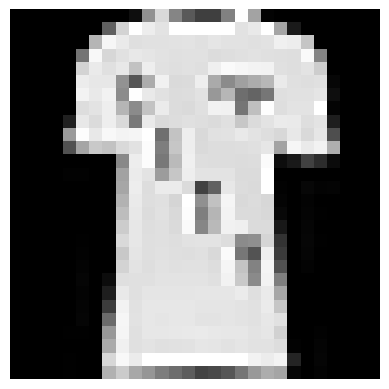

Is this a tank top? (y/n): n


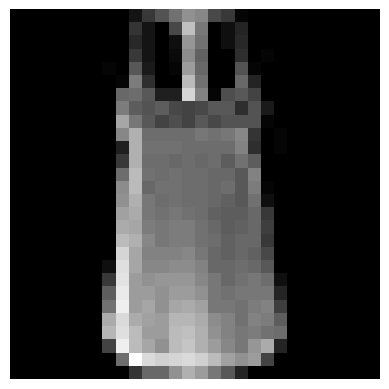

Is this a tank top? (y/n): y


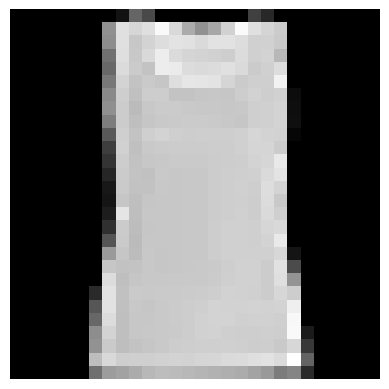

Is this a tank top? (y/n): y


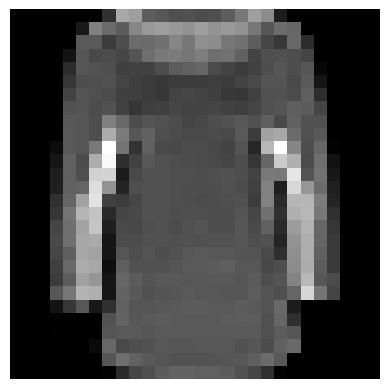

Is this a tank top? (y/n): n


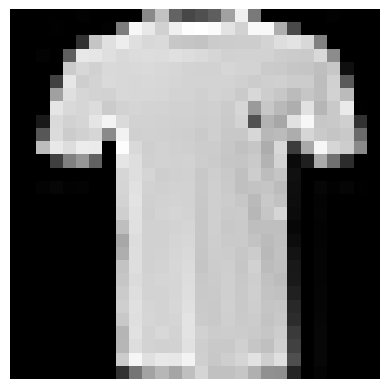

Is this a tank top? (y/n): n


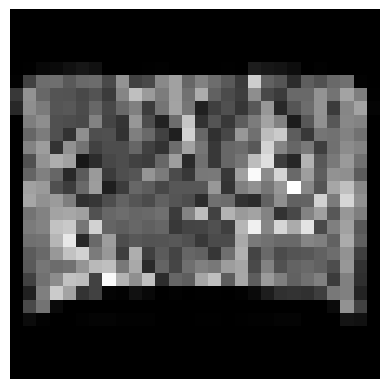

Is this a tank top? (y/n): n


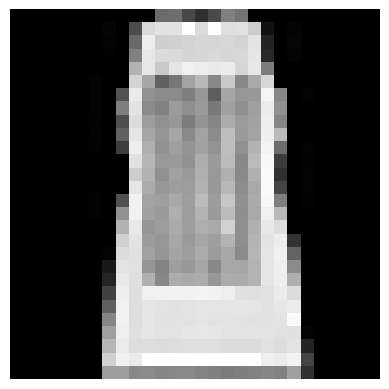

Is this a tank top? (y/n): y


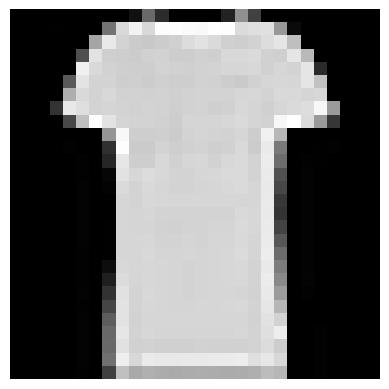

Is this a tank top? (y/n): n


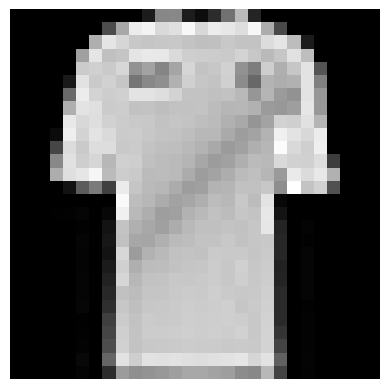

Is this a tank top? (y/n): n
Epoch 1/5
3/3 - 2s - 704ms/step - accuracy: 0.3000 - loss: 0.7189
Epoch 2/5
3/3 - 0s - 41ms/step - accuracy: 0.7000 - loss: 0.6655
Epoch 3/5
3/3 - 0s - 38ms/step - accuracy: 0.6000 - loss: 0.6466
Epoch 4/5
3/3 - 0s - 39ms/step - accuracy: 0.6500 - loss: 0.6235
Epoch 5/5
3/3 - 0s - 47ms/step - accuracy: 0.8000 - loss: 0.5793
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


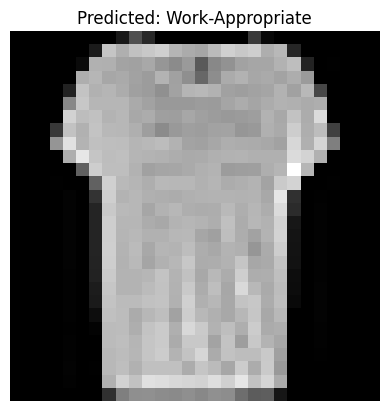

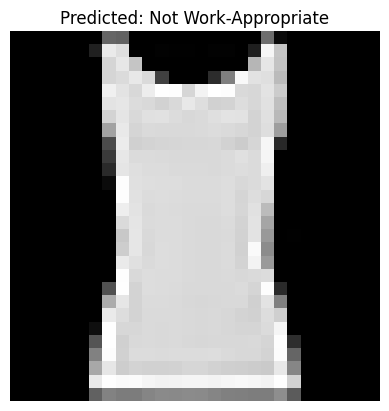

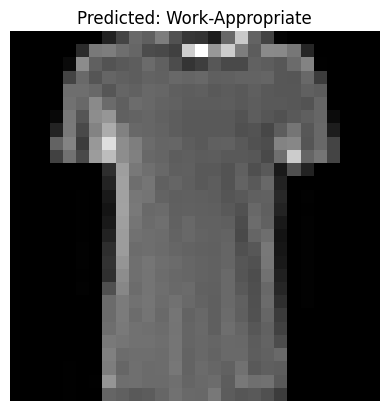

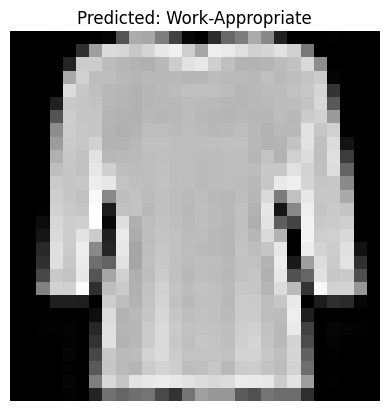

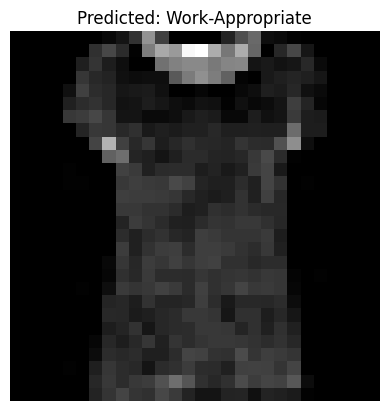

In [ ]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, Input
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Setting the RANDOM_STATE
# A number used to initialize the random number generators in Python, NumPy, TensorFlow
# Ensures that results are reproducible
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Preparing the Tank Top Dataset
# Load Fashion MNIST again (original train set)
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train_orig, y_train_orig), (X_test_orig, y_test_orig) = fashion_mnist.load_data()

# Normalize images
X_train_orig = X_train_orig / 255.0
X_test_orig = X_test_orig / 255.0

# Flatten images for main DNN
X_train_flat = X_train_orig.reshape(-1, 28*28)
X_test_flat = X_test_orig.reshape(-1, 28*28)

# Work-appropriate binary labels
# Class indices:
# 0=T-shirt/top, 1=Trouser, 2=Pullover, 3=Dress, 4=Coat,
# 5=Sandal, 6=Shirt, 7=Sneaker, 8=Bag, 9=Ankle boot

# Include class 0 (T-shirt/top) as work-appropriate
work_classes = [0,1,2,3,4,6]

y_train_binary = np.array([1 if label in work_classes else 0 for label in y_train_orig])
y_test_binary  = np.array([1 if label in work_classes else 0 for label in y_test_orig])

# One-hot encode
y_train_binary = to_categorical(y_train_binary, 2)
y_test_binary  = to_categorical(y_test_binary, 2)

# Train/val split
X_train_flat, X_val_flat, y_train_bin, y_val_bin = train_test_split(
    X_train_flat, y_train_binary, test_size=0.2, random_state=RANDOM_STATE
)

# compile_and_fit
def compile_and_fit(model, loss_function, optimizer, metrics, epochs, batch_size):
    model.compile(optimizer=optimizer, loss=loss_function, metrics=metrics)
    history = model.fit(
        X_train_flat, y_train_bin,
        validation_data=(X_val_flat, y_val_bin),
        epochs=epochs,
        batch_size=batch_size,
        verbose=2
    )
    return history

# Main model (Work-appropriate vs Not work-appropriate)
main_model = Sequential([
    Input(shape=(28*28,)),
    Dense(128, activation='relu'),
    Dense(2, activation='softmax')
])

history_main = compile_and_fit(
    model=main_model,
    loss_function='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'],
    epochs=10,
    batch_size=32
)

# Tank-top CNN classifier
# Select T-shirt/top images only
tshirt_indices = np.where(y_train_orig == 0)[0]
X_tshirts = X_train_orig[tshirt_indices]
y_tshirts_labels = np.zeros(len(X_tshirts))
# 0=normal, 1=tank

# Manual labeling (small subset)
NUM_TO_LABEL = 50
indices = list(range(len(X_tshirts)))
random.shuffle(indices)
indices = indices[:NUM_TO_LABEL]

for i in indices:
    plt.imshow(X_tshirts[i], cmap='gray')
    plt.axis('off')
    plt.show()
    label = input("Is this a tank top? (y/n): ").strip().lower()
    if label == 'y':
        y_tshirts_labels[i] = 1

# Balance labels (drop extras if imbalanced)
pos_idx = np.where(y_tshirts_labels == 1)[0]
neg_idx = np.where(y_tshirts_labels == 0)[0]
min_count = min(len(pos_idx), len(neg_idx))
balanced_idx = np.concatenate([pos_idx[:min_count], neg_idx[:min_count]])

X_tank_train = X_tshirts[balanced_idx].reshape(-1,28,28,1)
y_tank_train = y_tshirts_labels[balanced_idx]

# Define CNN
tank_model = Sequential([
    Input(shape=(28,28,1)),
    # Convolutional Layer #1
    # 32 filters (feature detectors), each filter 3x3
    # relu: non-linearity
    Conv2D(32,(3,3), activation='relu'),
    # Max pooling layer #1
    # To reduce computation and extract dominant features
    MaxPooling2D((2,2)),
    # Convolutional Layer #2
    # To extract more complex features from previous layer
    Conv2D(64,(3,3), activation='relu'),
    # Max pooling layer #2
    MaxPooling2D((2,2)),
    # Flatten layer
    Flatten(),
    # Dense layer
    Dense(64, activation='relu'),
    # Dropout layer
    Dropout(0.3),
    # Output layer
    Dense(1, activation='sigmoid')
])

tank_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
tank_model.fit(X_tank_train, y_tank_train, epochs=5, batch_size=8, verbose=2)

# Apply both models
# Filter only T-shirts/tops (class 0 in Fashion MNIST)
# indices of T-shirts/tops
tshirt_test_indices = np.where(y_test_orig == 0)[0]
X_test_tops = X_test_orig[tshirt_test_indices].reshape(-1,28,28,1)
y_test_tops = y_test_binary[tshirt_test_indices]

# Get work-appropriate predictions for T-shirts/tops
y_pred_binary_tops = np.argmax(main_model.predict(X_test_tops.reshape(-1,28*28)), axis=-1)

# Get tank top predictions
tank_probs = tank_model.predict(X_test_tops, verbose=0).flatten()

# Apply tank top rule
for i in range(len(y_pred_binary_tops)):
    if tank_probs[i] > 0.5:    # Tank top detected
        y_pred_binary_tops[i] = 0  # Set to Not Work-Appropriate

# Display results for random T-shirt/top samples
for _ in range(5):
    idx = random.randint(0, len(X_test_tops)-1)
    plt.imshow(X_test_tops[idx].reshape(28,28), cmap='gray')
    plt.axis('off')
    plt.title(f"Predicted: {['Not Work-Appropriate','Work-Appropriate'][y_pred_binary_tops[idx]]}")
    plt.show()